In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 전처리
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# 성능 지표
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, mean_absolute_percentage_error)

# 변수 중요도
from sklearn.inspection import permutation_importance

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print("라이브러리 임포트 완료")

라이브러리 임포트 완료


In [11]:
df = pd.read_csv('insurance.csv')

print(f"데이터 크기: {df.shape}")
print(f"\n컬럼 및 타입:")
print(df.dtypes)
print(f"\n결측값:")
print(df.isnull().sum())
print(f"\n기초 통계:")
print(df.describe())
df.head()

데이터 크기: (1338, 7)

컬럼 및 타입:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

결측값:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

기초 통계:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


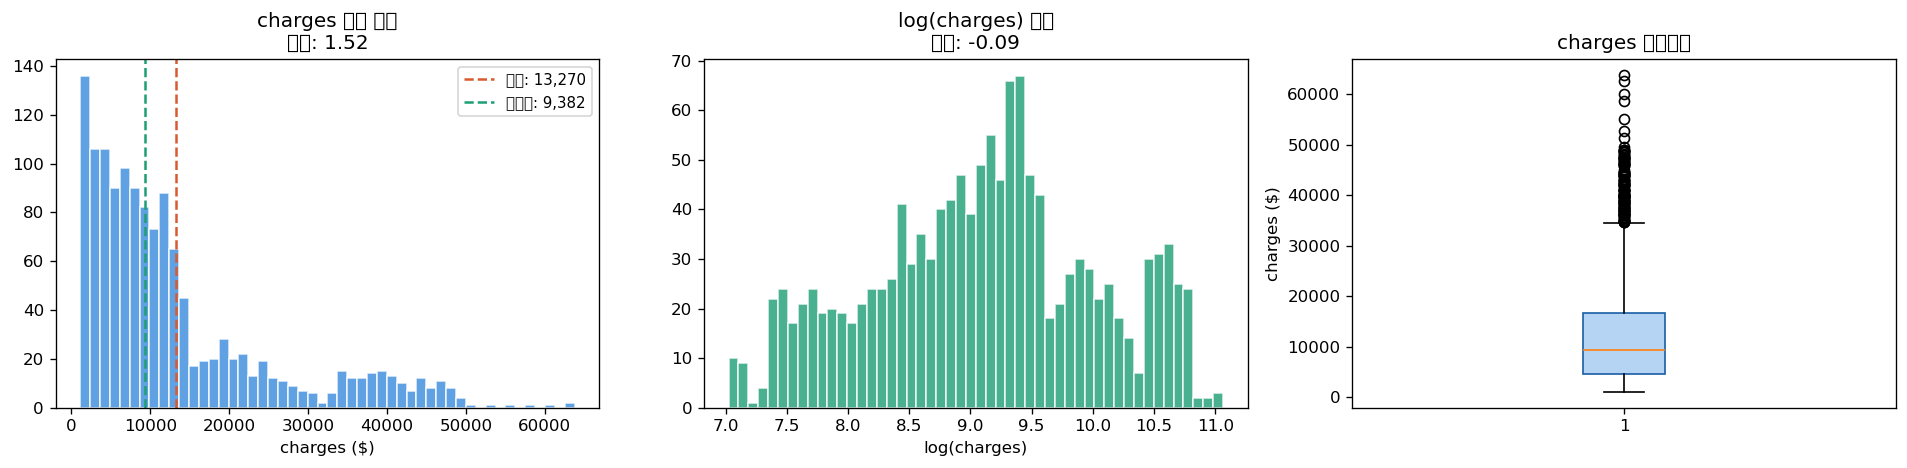

왜도: 1.516  |  첨도: 1.606


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 원본 분포
axes[0].hist(df['charges'], bins=50, color='#378ADD', alpha=0.8, edgecolor='white')
axes[0].axvline(df['charges'].mean(), color='#D85A30', linestyle='--',
                label=f"평균: {df['charges'].mean():,.0f}")
axes[0].axvline(df['charges'].median(), color='#1D9E75', linestyle='--',
                label=f"중앙값: {df['charges'].median():,.0f}")
axes[0].set_title(f'charges 원본 분포\n왜도: {df["charges"].skew():.2f}')
axes[0].set_xlabel('charges ($)')
axes[0].legend(fontsize=9)

# 로그 변환 후 분포
log_charges = np.log1p(df['charges'])
axes[1].hist(log_charges, bins=50, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].set_title(f'log(charges) 분포\n왜도: {log_charges.skew():.2f}')
axes[1].set_xlabel('log(charges)')

# 박스플롯
axes[2].boxplot(df['charges'], patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#185FA5'))
axes[2].set_title('charges 박스플롯')
axes[2].set_ylabel('charges ($)')

plt.tight_layout()
plt.show()
print(f"왜도: {df['charges'].skew():.3f}  |  첨도: {df['charges'].kurt():.3f}")

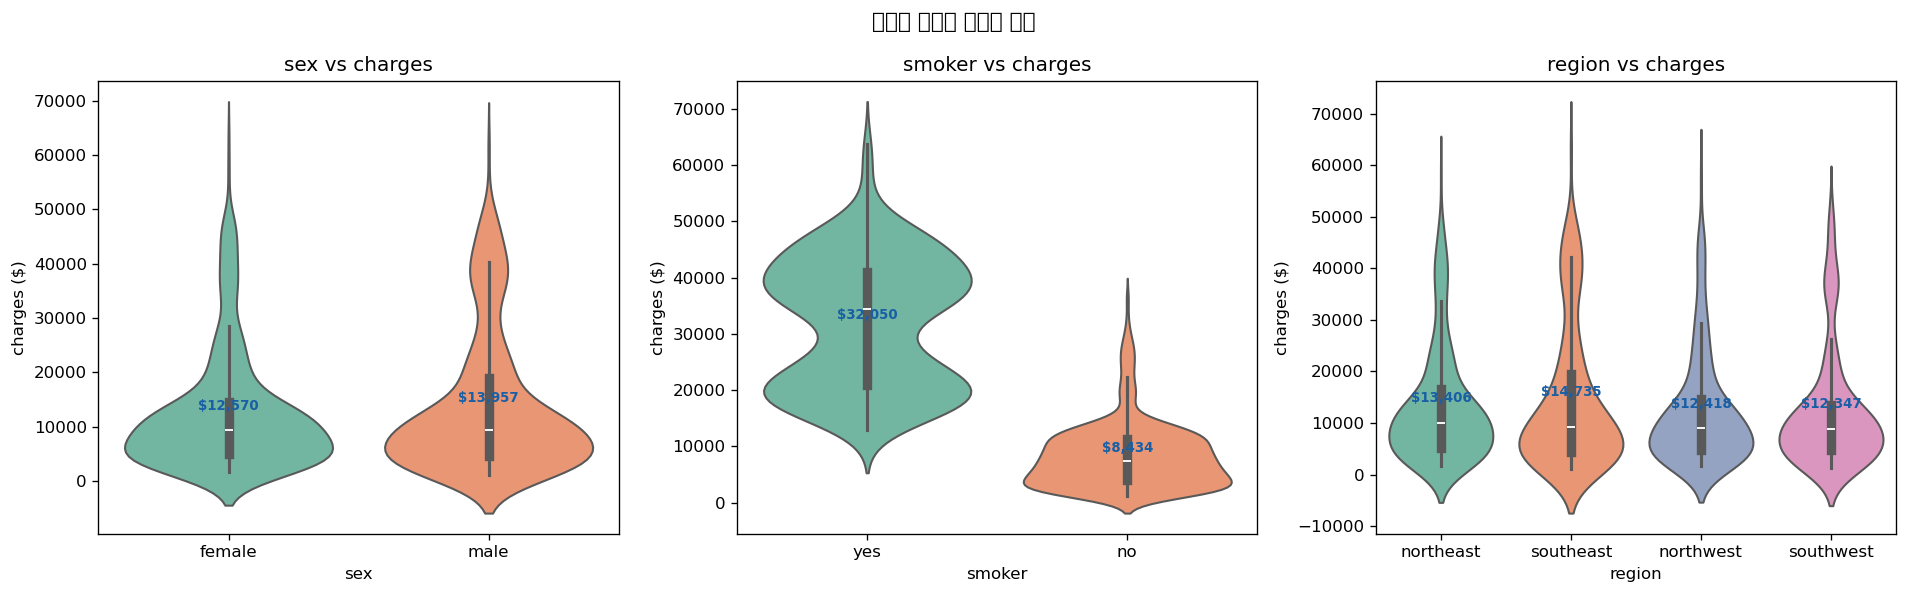

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_cols = ['sex', 'smoker', 'region']

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['charges'].median().sort_values(ascending=False).index
    sns.violinplot(x=col, y='charges', data=df, ax=axes[i],
                   order=order, palette='Set2', inner='box')
    axes[i].set_title(f'{col} vs charges')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges ($)')
    # 그룹별 평균 표시
    for j, grp in enumerate(order):
        mean_val = df[df[col]==grp]['charges'].mean()
        axes[i].text(j, mean_val, f'${mean_val:,.0f}',
                     ha='center', va='bottom', fontsize=8, color='#185FA5', fontweight='bold')

plt.suptitle('범주형 변수별 의료비 분포', fontsize=13)
plt.tight_layout()
plt.show()

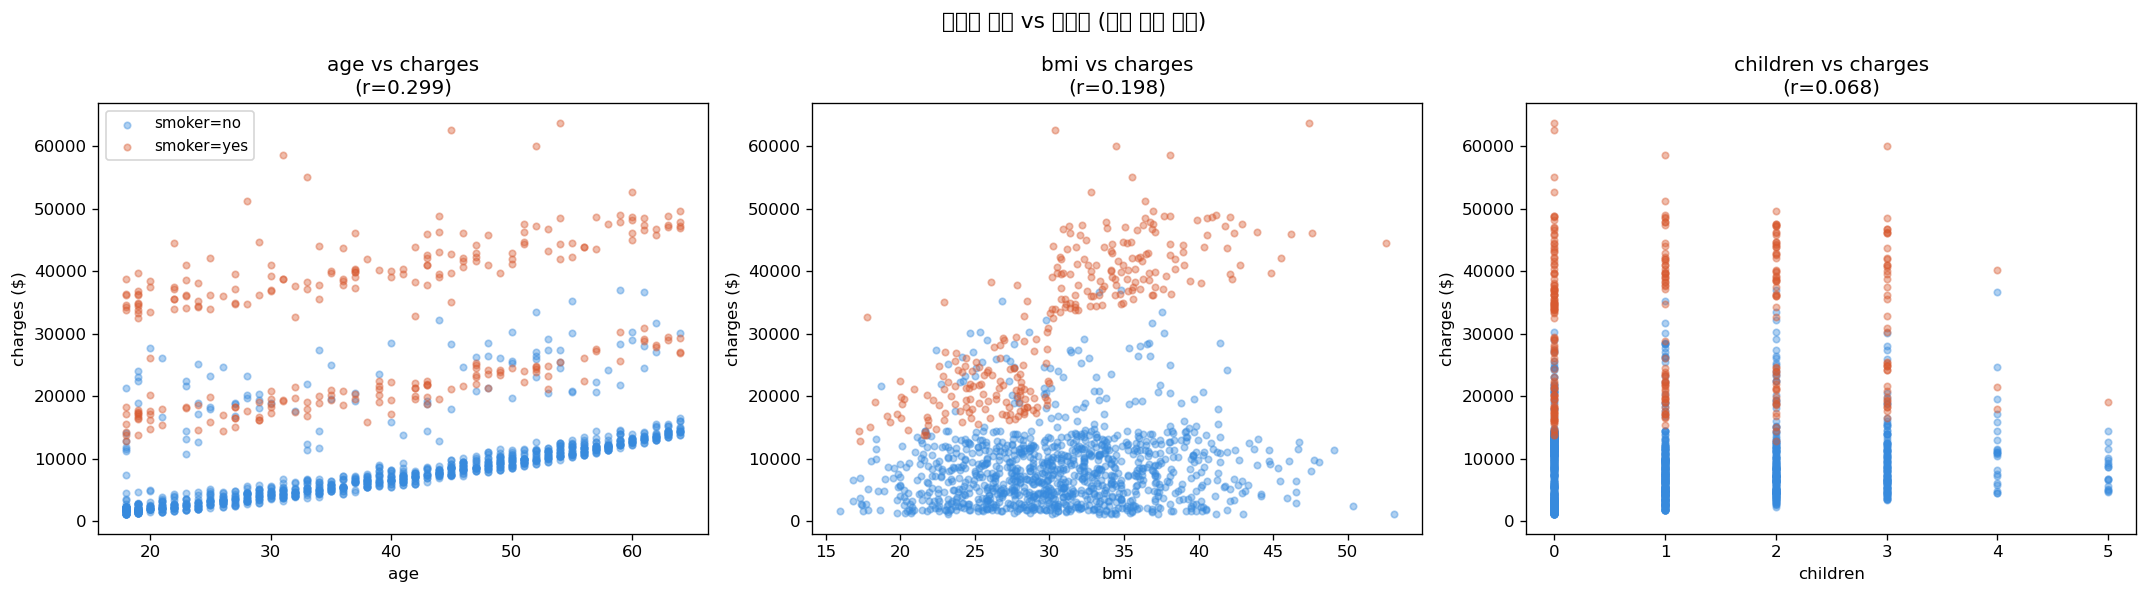

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
num_cols = ['age', 'bmi', 'children']
colors = {'yes': '#D85A30', 'no': '#378ADD'}

for i, col in enumerate(num_cols):
    for smoker, grp in df.groupby('smoker'):
        axes[i].scatter(grp[col], grp['charges'],
                        alpha=0.4, s=15, color=colors[smoker], label=f'smoker={smoker}')
    axes[i].set_title(f'{col} vs charges\n(r={df[col].corr(df["charges"]):.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges ($)')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('수치형 변수 vs 의료비 (흡연 여부 구분)', fontsize=13)
plt.tight_layout()
plt.show()

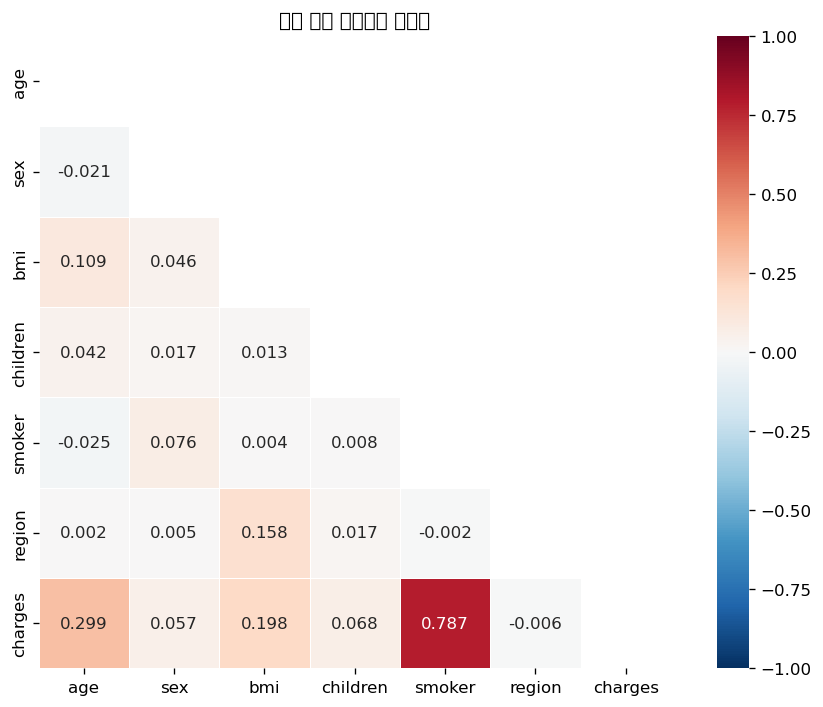


charges와의 상관계수 순위:
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208
Name: charges, dtype: float64


In [19]:
df_enc = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_enc[col] = le.fit_transform(df_enc[col])

plt.figure(figsize=(8, 6))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('전체 변수 상관관계 히트맵')
plt.tight_layout()
plt.show()

print("\ncharges와의 상관계수 순위:")
print(corr['charges'].drop('charges').sort_values(ascending=False))

In [21]:
df_feat = df.copy()

# 1. 비만 여부 (BMI ≥ 30)
df_feat['obese'] = (df_feat['bmi'] >= 30).astype(int)

# 2. 흡연 여부 이진화
df_feat['smoker_bin'] = (df_feat['smoker'] == 'yes').astype(int)

# 3. 핵심 상호작용 변수: 흡연 × 비만
df_feat['smoker_obese'] = df_feat['smoker_bin'] * df_feat['obese']

# 4. 나이 × 흡연
df_feat['age_smoker'] = df_feat['age'] * df_feat['smoker_bin']

# 5. BMI × 흡연
df_feat['bmi_smoker'] = df_feat['bmi'] * df_feat['smoker_bin']

# 6. 자녀 여부 (0 vs 1+)
df_feat['has_children'] = (df_feat['children'] > 0).astype(int)

print("파생변수 추가 후 컬럼:")
print(list(df_feat.columns))
print(f"\n흡연+비만 학생 수: {df_feat['smoker_obese'].sum()}명")
print(f"흡연+비만 평균 의료비: ${df_feat[df_feat['smoker_obese']==1]['charges'].mean():,.0f}")
print(f"비해당 평균 의료비:    ${df_feat[df_feat['smoker_obese']==0]['charges'].mean():,.0f}")

파생변수 추가 후 컬럼:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'obese', 'smoker_bin', 'smoker_obese', 'age_smoker', 'bmi_smoker', 'has_children']

흡연+비만 학생 수: 145명
흡연+비만 평균 의료비: $41,558
비해당 평균 의료비:    $9,832


In [23]:
# 원본 features / target 설정
feature_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region',
                'obese', 'smoker_obese', 'age_smoker', 'bmi_smoker', 'has_children']
X = df_feat[feature_cols]
y = df_feat['charges']
y_log = np.log1p(y)   # 선형 모델용 로그 변환 타깃

# Train / Test 분리 (80:20, stratify 불가→random_state 고정)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
_, _, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# 수치형 / 범주형 컬럼 정의
num_features = ['age', 'bmi', 'children', 'obese',
                'smoker_obese', 'age_smoker', 'bmi_smoker', 'has_children']
cat_features = ['sex', 'smoker', 'region']

# ColumnTransformer: 수치형→StandardScaler, 범주형→OneHotEncoder
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

# Train 기준으로 fit, Test에 transform만 적용 (데이터 누수 방지)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"전처리 후 Train: {X_train_proc.shape}")
print(f"전처리 후 Test:  {X_test_proc.shape}")

Train: (1070, 11)  |  Test: (268, 11)
전처리 후 Train: (1070, 13)
전처리 후 Test:  (268, 13)


In [25]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=10),
    'Lasso':            Lasso(alpha=10),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200,
                                                   learning_rate=0.1,
                                                   max_depth=4,
                                                   random_state=42),
}

results = {}

for name, model in models.items():
    # 선형 모델: log 타깃 사용
    if name in ['LinearRegression', 'Ridge', 'Lasso']:
        model.fit(X_train_proc, y_log_train)
        y_pred_log = model.predict(X_test_proc)
        y_pred = np.expm1(y_pred_log)   # 역변환
        y_true = y_test
    else:
        model.fit(X_train_proc, y_train)
        y_pred = model.predict(X_test_proc)
        y_true = y_test

    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    results[name] = {'R²': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE(%)': mape}
    print(f"{name:<20} R²={r2:.3f}  RMSE={rmse:>9,.0f}  MAE={mae:>8,.0f}  MAPE={mape:.1f}%")

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print("\n=== 모델 성능 순위 ===")
print(results_df.round(3))

LinearRegression     R²=0.859  RMSE=    4,685  MAE=   2,356  MAPE=17.8%
Ridge                R²=0.793  RMSE=    5,665  MAE=   2,633  MAPE=19.6%
Lasso                R²=-0.098  RMSE=   13,054  MAE=   8,603  MAPE=107.5%
RandomForest         R²=0.864  RMSE=    4,599  MAE=   2,557  MAPE=32.1%
GradientBoosting     R²=0.850  RMSE=    4,818  MAE=   2,683  MAPE=30.2%

=== 모델 성능 순위 ===
                     R²       RMSE       MAE  MAPE(%)
RandomForest      0.864   4598.838  2557.141   32.141
LinearRegression  0.859   4685.279  2356.110   17.791
GradientBoosting  0.850   4817.896  2683.372   30.232
Ridge             0.793   5665.138  2633.460   19.643
Lasso            -0.098  13053.719  8603.157  107.497


In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'모델':<22} {'CV R² 평균':>10} {'표준편차':>10} {'안정성'}")
print("-" * 60)

cv_results = {}
for name, model in models.items():
    if name in ['LinearRegression', 'Ridge', 'Lasso']:
        scores = cross_val_score(model, X_train_proc, y_log_train,
                                 cv=kf, scoring='r2')
    else:
        scores = cross_val_score(model, X_train_proc, y_train,
                                 cv=kf, scoring='r2')
    cv_results[name] = scores
    stability = '안정' if scores.std() < 0.03 else '보통' if scores.std() < 0.06 else '불안정'
    print(f"{name:<22} {scores.mean():>10.3f} {scores.std():>10.3f}  {stability}")

print("\n→ 표준편차가 낮을수록 데이터 분할에 강건한 모델")

모델                       CV R² 평균       표준편차 안정성
------------------------------------------------------------
LinearRegression            0.818      0.036  보통
Ridge                       0.809      0.032  보통
Lasso                      -0.006      0.009  안정
RandomForest                0.830      0.027  안정
GradientBoosting            0.826      0.030  보통

→ 표준편차가 낮을수록 데이터 분할에 강건한 모델


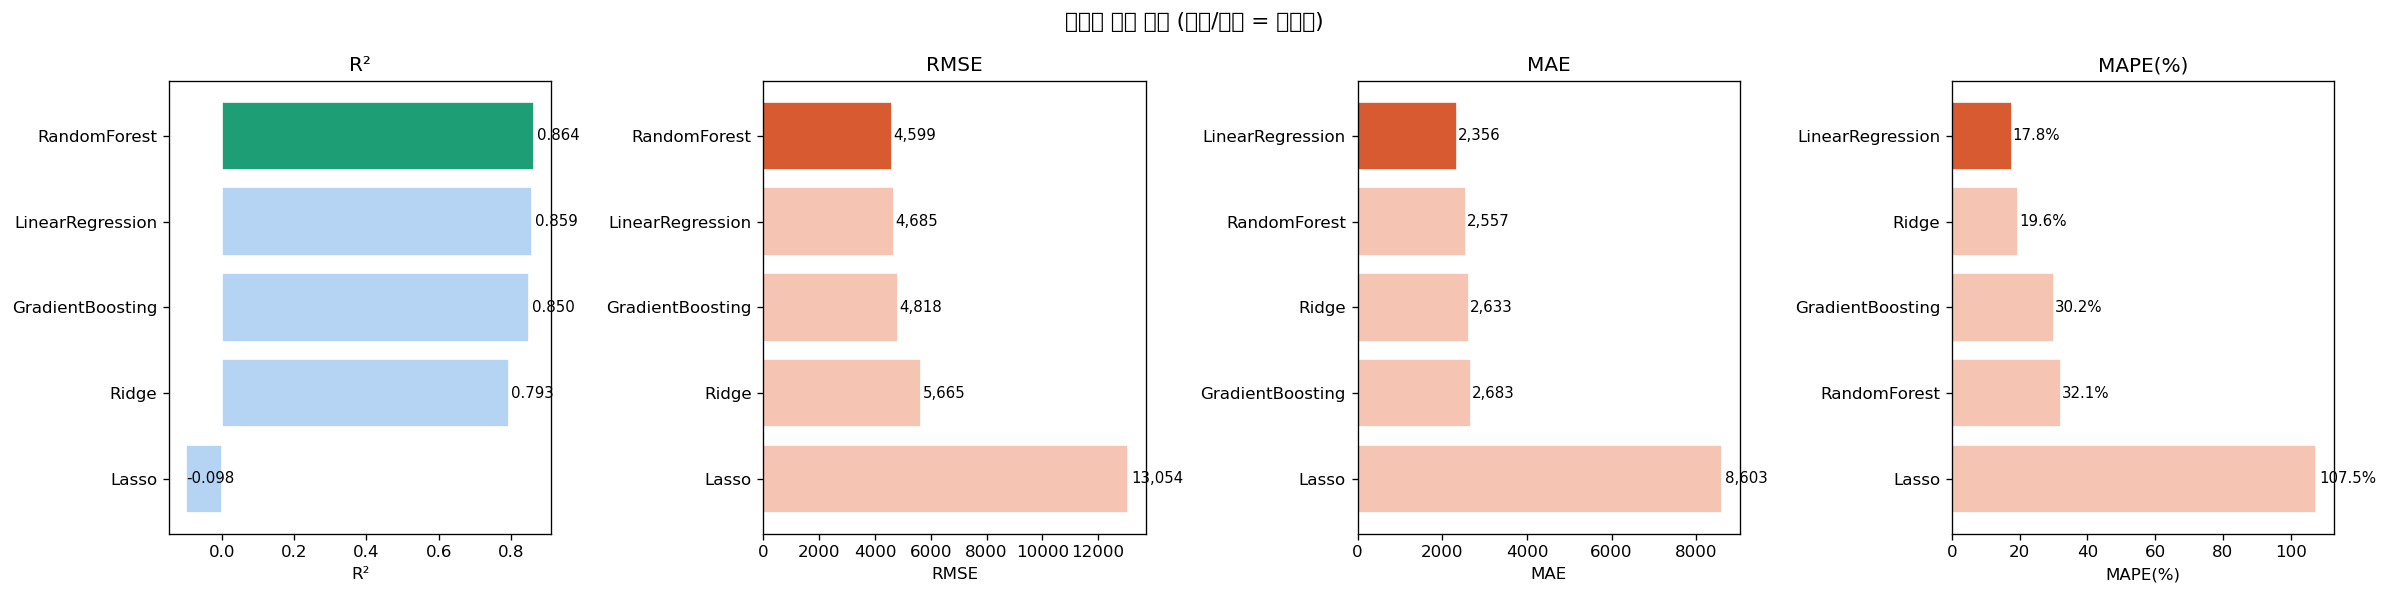

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['R²', 'RMSE', 'MAE', 'MAPE(%)']
colors_model = ['#B5D4F4','#B5D4F4','#B5D4F4','#5DCAA5','#1D9E75']

for i, metric in enumerate(metrics):
    vals = results_df[metric]
    if metric == 'R²':
        order = vals.sort_values(ascending=True)
        bar_colors = ['#1D9E75' if v == vals.max() else '#B5D4F4' for v in order]
    else:
        order = vals.sort_values(ascending=False)
        bar_colors = ['#D85A30' if v == vals.min() else '#F5C4B3' for v in order]

    bars = axes[i].barh(order.index, order.values, color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, order.values):
        fmt = f'{val:.3f}' if metric == 'R²' else f'{val:,.0f}' if metric in ['RMSE','MAE'] else f'{val:.1f}%'
        axes[i].text(bar.get_width() + bar.get_width()*0.01,
                     bar.get_y() + bar.get_height()/2,
                     fmt, va='center', fontsize=9)
    axes[i].set_title(metric)
    axes[i].set_xlabel(metric)

plt.suptitle('모델별 성능 비교 (초록/빨강 = 최우수)', fontsize=13)
plt.tight_layout()
plt.show()

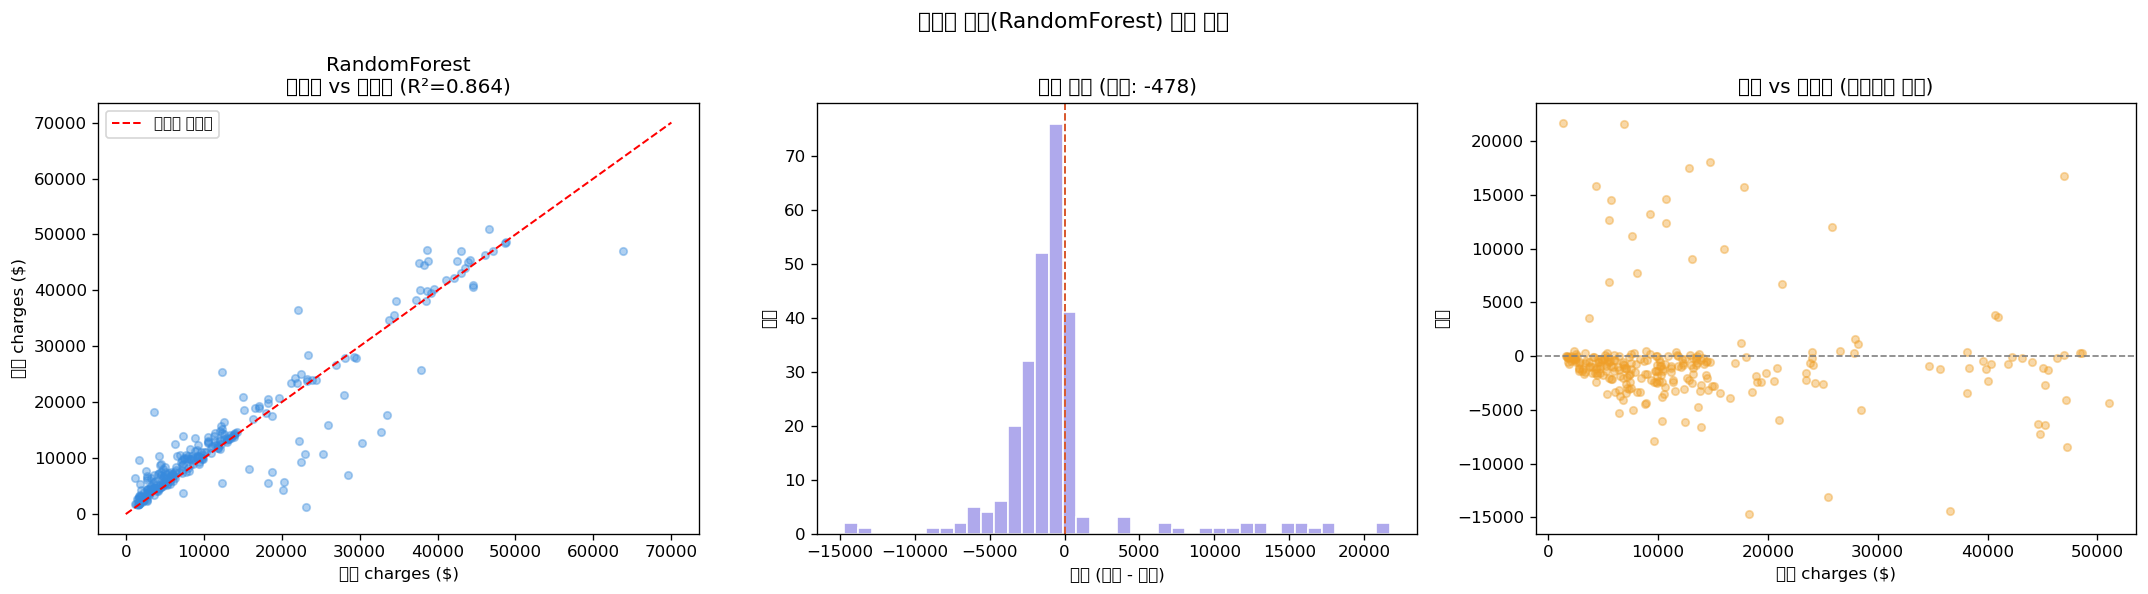

In [31]:
best_name = results_df['R²'].idxmax()
best_model = models[best_name]

if best_name in ['LinearRegression', 'Ridge', 'Lasso']:
    y_pred_best = np.expm1(best_model.predict(X_test_proc))
else:
    y_pred_best = best_model.predict(X_test_proc)

residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 산점도
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='#378ADD', s=20)
lim = [0, 70000]
axes[0].plot(lim, lim, 'r--', linewidth=1.2, label='완벽한 예측선')
axes[0].set_xlabel('실제 charges ($)')
axes[0].set_ylabel('예측 charges ($)')
axes[0].set_title(f'{best_name}\n실제값 vs 예측값 (R²={results_df.loc[best_name,"R²"]:.3f})')
axes[0].legend(fontsize=9)

# 잔차 분포
axes[1].hist(residuals, bins=40, color='#AFA9EC', edgecolor='white')
axes[1].axvline(0, color='#D85A30', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('잔차 (실제 - 예측)')
axes[1].set_ylabel('빈도')
axes[1].set_title(f'잔차 분포 (평균: {residuals.mean():,.0f})')

# 잔차 vs 예측값 (이분산성 확인)
axes[2].scatter(y_pred_best, residuals, alpha=0.4, color='#EF9F27', s=20)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].set_xlabel('예측 charges ($)')
axes[2].set_ylabel('잔차')
axes[2].set_title('잔차 vs 예측값 (이분산성 확인)')

plt.suptitle(f'최우수 모델({best_name}) 예측 진단', fontsize=13)
plt.tight_layout()
plt.show()

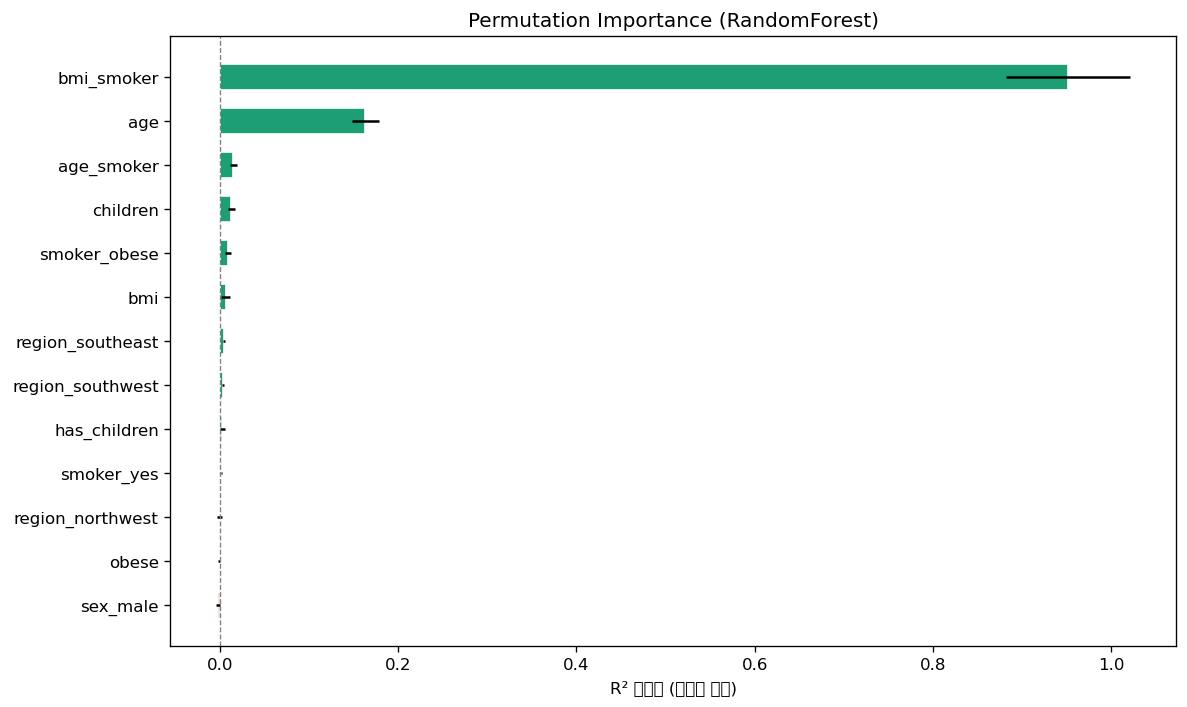

              변수    중요도 평균  중요도 표준편차
      bmi_smoker  0.952020  0.069568
             age  0.162933  0.015374
      age_smoker  0.014998  0.004280
        children  0.012812  0.003685
    smoker_obese  0.009021  0.003118
             bmi  0.006256  0.005004
region_southeast  0.004277  0.001215
region_southwest  0.003096  0.001397
    has_children  0.002747  0.002632
      smoker_yes  0.001252  0.000660
region_northwest -0.000134  0.002842
           obese -0.001040  0.001402
        sex_male -0.002411  0.001984


In [33]:
# 컬럼명 복원
ohe_cols = preprocessor.named_transformers_['cat']\
           .get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + ohe_cols

# Permutation Importance 계산
perm_imp = permutation_importance(best_model, X_test_proc, y_test,
                                  n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    '변수': all_feature_names,
    '중요도 평균': perm_imp.importances_mean,
    '중요도 표준편차': perm_imp.importances_std
}).sort_values('중요도 평균', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
colors_pi = ['#1D9E75' if v > 0 else '#D85A30' for v in perm_df['중요도 평균']]
plt.barh(perm_df['변수'][::-1], perm_df['중요도 평균'][::-1],
         xerr=perm_df['중요도 표준편차'][::-1],
         color=colors_pi[::-1], edgecolor='white', height=0.6)
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('R² 감소량 (클수록 중요)')
plt.title(f'Permutation Importance ({best_name})')
plt.tight_layout()
plt.show()

print(perm_df.to_string(index=False))

In [35]:
print("=" * 65)
print("최종 분석 결과 요약")
print("=" * 65)

print("\n[모델 성능 비교]")
print(results_df.round(3).to_string())

print("\n[주요 영향 변수 Top 5]")
print(perm_df.head(5)[['변수','중요도 평균']].to_string(index=False))

print(f"\n[최우수 모델] {best_name}")
print(f"  R²   : {results_df.loc[best_name,'R²']:.3f}  → 의료비 분산의 {results_df.loc[best_name,'R²']*100:.1f}% 설명")
print(f"  RMSE : ${results_df.loc[best_name,'RMSE']:>,.0f}  → 평균 예측 오차")
print(f"  MAE  : ${results_df.loc[best_name,'MAE']:>,.0f}  → 중앙 예측 오차")
print(f"  MAPE : {results_df.loc[best_name,'MAPE(%)']:.1f}%  → 실제값 대비 평균 오차율")

print("\n[개선점 적용 결과]")
improvements = [
    ("변수 선택 확장", "파생변수 5개 추가 (smoker_obese, age_smoker 등)"),
    ("Train/Test 분리", "80:20 분리 + 데이터 누수 방지"),
    ("다양한 모델",     "5개 모델 비교 (선형 3개 + 트리 2개)"),
    ("데이터 스케일링", "StandardScaler 적용 (선형 모델 성능 향상)"),
    ("성능 지표 다각화","R², RMSE, MAE, MAPE + 5-Fold 교차검증"),
]
for imp, desc in improvements:
    print(f"  ✓ {imp}: {desc}")

최종 분석 결과 요약

[모델 성능 비교]
                     R²       RMSE       MAE  MAPE(%)
RandomForest      0.864   4598.838  2557.141   32.141
LinearRegression  0.859   4685.279  2356.110   17.791
GradientBoosting  0.850   4817.896  2683.372   30.232
Ridge             0.793   5665.138  2633.460   19.643
Lasso            -0.098  13053.719  8603.157  107.497

[주요 영향 변수 Top 5]
          변수   중요도 평균
  bmi_smoker 0.952020
         age 0.162933
  age_smoker 0.014998
    children 0.012812
smoker_obese 0.009021

[최우수 모델] RandomForest
  R²   : 0.864  → 의료비 분산의 86.4% 설명
  RMSE : $4,599  → 평균 예측 오차
  MAE  : $2,557  → 중앙 예측 오차
  MAPE : 32.1%  → 실제값 대비 평균 오차율

[개선점 적용 결과]
  ✓ 변수 선택 확장: 파생변수 5개 추가 (smoker_obese, age_smoker 등)
  ✓ Train/Test 분리: 80:20 분리 + 데이터 누수 방지
  ✓ 다양한 모델: 5개 모델 비교 (선형 3개 + 트리 2개)
  ✓ 데이터 스케일링: StandardScaler 적용 (선형 모델 성능 향상)
  ✓ 성능 지표 다각화: R², RMSE, MAE, MAPE + 5-Fold 교차검증
